# Data Prep: Clustering

In this notebook, the final feature matrix will be prepared for module 1, where we will use an unsupervised clustering algorithm to assign PLR's to gentrification clusters. This includes a short EDA, dropping / transforming of variables and, finally, saving the final dataset.

## 1) Load packages + Data

In [189]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from matplotlib.patches import Patch

In [190]:
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr = gpd.read_file(url)
plr["plr_id"] = plr["plr_id"].astype(str).str.zfill(8)

In [191]:
print(type(plr))  

<class 'geopandas.geodataframe.GeoDataFrame'>


In [192]:
## load data 
df = pd.read_csv("/Users/mareikesahling/Ginger_Gradient/Capstone/capstone-kiezkeeper/data/final_datasets/feature_matrix_all_dimensions.csv",dtype={"plr_id": str})
df.sample(5)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_miete_unsicher,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_brw_trend_outlier,...,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_upscale_share_slope,com_tourism_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,com_has_gastro_structure
156,04300412,Schlossgarten,04 - Charlottenburg-Wilmersdorf,20.39,2.685,0,4.099330,3999.462213,-0.318412,0,...,0.001593,0.026454,-0.001634,-0.000146,0.088981,-0.000283,-0.002625,0.001368,8.666667,1
407,09301227,Karolinenhof,09 - Treptow-Köpenick,15.00,1.038,1,2.561247,430.000000,0.123614,0,...,0.000000,0.008392,0.002151,-0.000856,-0.025483,0.001630,0.001410,0.002636,2.000000,0
439,10100316,Landsberger Tor,10 - Marzahn-Hellersdorf,10.52,0.718,0,0.778643,591.077074,-0.217928,0,...,-0.001776,0.020683,-0.012813,-0.007645,0.077692,-0.001146,0.007830,0.002084,11.166667,1
300,07200414,Hohenfriedbergstraße,07 - Tempelhof-Schöneberg,20.58,1.629,1,1.283880,2836.366945,-0.228248,0,...,0.000421,-0.004530,0.000562,0.000663,0.077466,0.001513,-0.000825,0.003544,13.166667,1
221,05200524,Döberitzer Weg,05 - Spandau,9.94,0.560,1,2.145594,370.619782,-0.016392,0,...,-0.001021,-0.001378,0.003364,0.003744,-0.015367,0.000000,0.000021,0.004940,8.500000,1


In [193]:
df.shape

(542, 58)

In [194]:
#drop validation column for income
df.drop(columns=["soc_median_income_2023"], inplace = True)

#add interpretability variable for social dimension
# PLRs where the social dimension is NOT meaningfully interpretable because of too little inhabitants
#(non-residential: development sites, industrial estates, freight yard)
not_interpretable = {
    "03300515": "Blankenburger Süden",
    "03400831": "Pankower Tor",
    "04400725": "Güterbahnhof Grunewald",
    "05300838": "Gartenfeld",
    "06200418": "Landweg",
    "10100205": "Gewerbegebiet Bitterfelder Straße",
    "12200411": "Schumacher-Quartier",
    "05300840": "Nonnendammallee",
}

# map onto the dataframe — zero-pad the key so leading zeros match
key = df["plr_id"].astype(str).str.zfill(8)
df["social_dimension_interpretable"] = np.where(key.isin(not_interpretable), 0, 1)

# check: should be 8 'no'
print(df["social_dimension_interpretable"].value_counts())

social_dimension_interpretable
1    534
0      8
Name: count, dtype: int64


## 2) NA Overview & Drops

In [195]:
#look at missing values across columns
df.isna().sum().sort_values(ascending = False)

re_miete_trend                                                  16
re_miete_niveau                                                 11
soc_transfer_benefit_share_change_2020_2024                      7
soc_transfer_benefit_share_2024                                  7
com_upscale_share_level_2026                                     5
re_leerstandsquote                                               5
soc_single_parent_household_share_change_2021_2024               4
soc_young_to_middle_adult_share_2025                             4
com_upscale_share_slope                                          4
soc_young_to_middle_adult_share_change_2021_2025                 4
soc_single_parent_household_share_2024                           3
soc_households_without_minor_children_share_change_2021_2024     3
re_anteil_y2011_plus                                             2
soc_internal_net_migration_rate_change_2021_2025                 2
soc_internal_migration_volume_rate_change_2021_2025           

In [196]:
#look at missing values per plr 
id_cols = ["plr_id", "plr_name", "bez"]
feature_cols = [c for c in df.columns if c not in id_cols]


df["n_missing"] = df[feature_cols].isna().sum(axis=1)

missing_plrs = (
    df.loc[df["n_missing"] > 0, id_cols + ["n_missing"]]
      .sort_values("n_missing", ascending=False)
      .reset_index(drop=True)
)

pd.set_option("display.max_rows", None)
print(missing_plrs.to_string(index=False))
print(f"\n{len(missing_plrs)} PLRs with missing values, out of {len(df)} total")

  plr_id                          plr_name                             bez  n_missing
03400831                      Pankower Tor                     03 - Pankow         27
06200418                           Landweg        06 - Steglitz-Zehlendorf         27
05300838                        Gartenfeld                    05 - Spandau         11
10100205 Gewerbegebiet Bitterfelder Straße        10 - Marzahn-Hellersdorf          8
04400725            Güterbahnhof Grunewald 04 - Charlottenburg-Wilmersdorf          7
03300515               Blankenburger Süden                     03 - Pankow          7
12200411               Schumacher-Quartier              12 - Reinickendorf          4
07200412                Schöneberger Linse       07 - Tempelhof-Schöneberg          3
08200729                    Britzer Garten                   08 - Neukölln          2
09300921                  Preußen Siedlung           09 - Treptow-Köpenick          2
03300413                         Karow Ost            

In [197]:
# for each PLR with gaps, list the actual missing columns
for _, row in missing_plrs.iterrows():
    plr_row = df.loc[df["plr_id"] == row["plr_id"]].iloc[0]
    cols = [c for c in feature_cols if pd.isna(plr_row[c])]
    print(f'{row["plr_name"]} ({row["bez"]}) — {row["n_missing"]} missing:')
    print("   ", ", ".join(cols), "\n")

Pankower Tor (03 - Pankow) — 27 missing:
    re_miete_niveau, re_miete_trend, re_leerstandsquote, re_dichte_all, re_baualter_unsicher, re_anteil_vor_1919, re_anteil_y1919_1948, re_anteil_y1949_1978, re_anteil_y1979_1990, re_anteil_y1991_2000, re_anteil_y2001_2010, re_anteil_y2011_plus, soc_young_to_middle_adult_share_2025, soc_young_to_middle_adult_share_change_2021_2025, soc_single_person_hh_share_2024, soc_single_person_hh_share_change_2021_2024, soc_households_without_minor_children_share_2024, soc_households_without_minor_children_share_change_2021_2024, soc_internal_migration_volume_rate_2025, soc_internal_migration_volume_rate_change_2021_2025, soc_internal_net_migration_rate_2025, soc_internal_net_migration_rate_change_2021_2025, soc_transfer_benefit_share_2024, soc_transfer_benefit_share_change_2020_2024, soc_single_parent_household_share_2024, soc_single_parent_household_share_change_2021_2024, com_upscale_share_level_2026 

Landweg (06 - Steglitz-Zehlendorf) — 27 missing:
   

### Plot: NA per PLR

542 von 542 gematcht


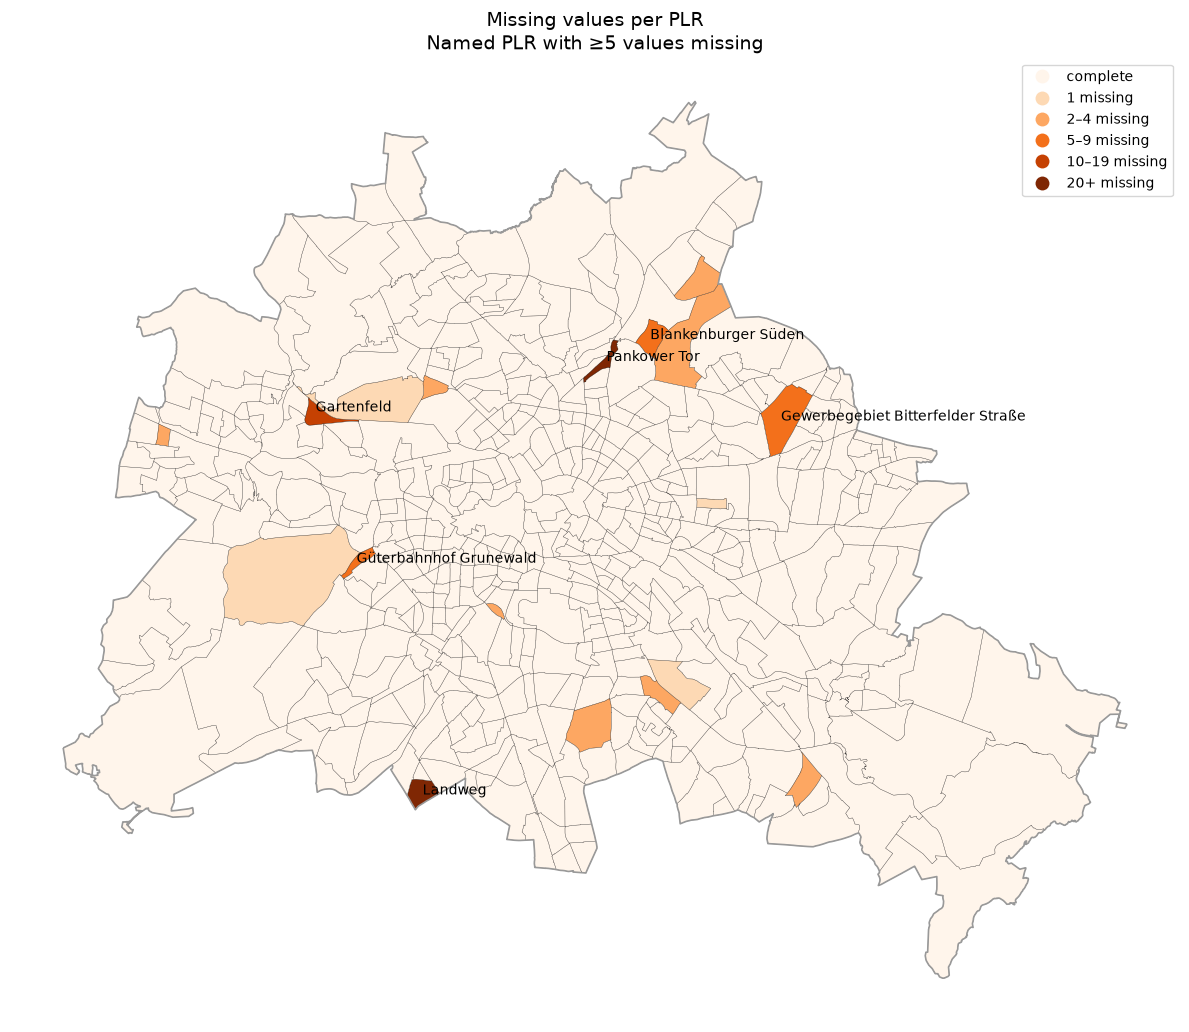

In [198]:
# recompute n_missing + zero-padded join key
id_cols = ["plr_id", "plr_name", "bez"]
feature_cols = [c for c in df.columns if c not in id_cols]
df["n_missing"] = df[feature_cols].isna().sum(axis=1)

# join the counts onto the geometries
gdf = plr.merge(
    df.assign(plr_id=df["plr_id"].astype(str).str.zfill(8))[["plr_id", "n_missing"]],
    on="plr_id", how="left"
)

# sanity check — sollte ~542 sein
print(gdf["n_missing"].notna().sum(), "von", len(gdf), "gematcht")

berlin_outline = plr.dissolve()

# bin categories 
bins   = [-1, 0, 1, 4, 9, 19, np.inf]
labels = ["complete", "1 missing", "2–4 missing",
          "5–9 missing", "10–19 missing", "20+ missing"]
gdf["missing_cat"] = pd.cut(
    gdf["n_missing"].fillna(0),
    bins=bins,
    labels=labels
)

# 
fig, ax = plt.subplots(figsize=(12, 12))

# plot on map 
gdf.plot(
    column="missing_cat",
    categorical=True,
    legend=True,
    cmap="Oranges",
    edgecolor="none",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "no geometry match"}
)

# alle plr boundary
gdf.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.25,
    alpha=0.5
)

# berlin boundary
berlin_outline.boundary.plot(
    ax=ax,
    edgecolor="#999999",
    linewidth=1.2
)

ax.set_title(
    "Missing values per PLR\nNamed PLR with ≥5 values missing",
    fontsize=14
)
ax.axis("off")

# worst offenders
for _, r in gdf[gdf["n_missing"] >= 5].iterrows():
    c = r.geometry.representative_point()
    ax.annotate(
        r["plr_name"],
        (c.x, c.y),
        fontsize=10,
        ha="left"
    )

plt.tight_layout()
plt.show()

In [199]:
#drop PLR's with more than 3 NA columns
id_cols = ["plr_id", "plr_name", "bez"]
feature_cols = [c for c in df.columns if c not in id_cols + ["n_missing"]]
df["n_missing"] = df[feature_cols].isna().sum(axis=1)

# show what's about to go
dropped = df.loc[df["n_missing"] > 3, ["plr_name", "bez", "n_missing"]]
print("Dropping", len(dropped), "PLRs:")
print(dropped.sort_values("n_missing", ascending=False).to_string(index=False))

df_clean = df.loc[df["n_missing"] <= 3].copy()
print(f"\n{len(df)} -> {len(df_clean)} PLRs")

Dropping 7 PLRs:
                         plr_name                             bez  n_missing
                     Pankower Tor                     03 - Pankow         27
                          Landweg        06 - Steglitz-Zehlendorf         27
                       Gartenfeld                    05 - Spandau         11
Gewerbegebiet Bitterfelder Straße        10 - Marzahn-Hellersdorf          8
              Blankenburger Süden                     03 - Pankow          7
           Güterbahnhof Grunewald 04 - Charlottenburg-Wilmersdorf          7
              Schumacher-Quartier              12 - Reinickendorf          4

542 -> 535 PLRs


In [200]:
#s for each PLR with gaps, list the actual missing columns
# rebuild the missing-value list FROM the cleaned frame
id_cols = ["plr_id", "plr_name", "bez"]
feature_cols = [c for c in df_clean.columns if c not in id_cols + ["n_missing"]]
df_clean["n_missing"] = df_clean[feature_cols].isna().sum(axis=1)

missing_clean = (
    df_clean.loc[df_clean["n_missing"] > 0, id_cols + ["n_missing"]]
            .sort_values("n_missing", ascending=False)
)

for _, row in missing_clean.iterrows():
    plr_row = df_clean.loc[df_clean["plr_id"] == row["plr_id"]].iloc[0]
    cols = [c for c in feature_cols if pd.isna(plr_row[c])]
    print(f'{row["plr_name"]} ({row["bez"]}) — {int(row["n_missing"])} missing:')
    print("   ", ", ".join(cols), "\n")

Schöneberger Linse (07 - Tempelhof-Schöneberg) — 3 missing:
    re_brw_niveau, re_brw_trend, re_cov_wohnen_2025 

Karow Ost (03 - Pankow) — 2 missing:
    re_miete_niveau, re_miete_trend 

Märchenland (03 - Pankow) — 2 missing:
    re_miete_niveau, re_miete_trend 

Am Heideberg (05 - Spandau) — 2 missing:
    re_miete_niveau, re_miete_trend 

Ortolanweg (08 - Neukölln) — 2 missing:
    re_miete_niveau, re_miete_trend 

Britzer Garten (08 - Neukölln) — 2 missing:
    re_miete_niveau, re_miete_trend 

Preußen Siedlung (09 - Treptow-Köpenick) — 2 missing:
    com_upscale_share_level_2026, com_upscale_share_slope 

Eichkamp (04 - Charlottenburg-Wilmersdorf) — 1 missing:
    re_miete_trend 

Späthsfelde (09 - Treptow-Köpenick) — 1 missing:
    re_miete_trend 

Bornitzstraße (11 - Lichtenberg) — 1 missing:
    re_miete_trend 

TXL (12 - Reinickendorf) — 1 missing:
    re_miete_trend 



In [202]:
#inspect NA for gastro variables 
pid = "09300921"   # Preußen Siedlung — swap for any other plr_id

key = df_clean["plr_id"].astype(str).str.zfill(8)
row = df_clean.loc[key == pid].T          # transpose: variables become rows
row.columns = ["value"]

with pd.option_context("display.max_rows", None):
    print(row.to_string())

                                                                              value
plr_id                                                                     09300921
plr_name                                                           Preußen Siedlung
bez                                                           09 - Treptow-Köpenick
re_miete_niveau                                                               12.08
re_miete_trend                                                                0.738
re_miete_unsicher                                                                 1
re_leerstandsquote                                                         2.453988
re_brw_niveau                                                            489.689649
re_brw_trend                                                               0.064568
re_brw_trend_outlier                                                              0
re_cov_wohnen_2025                                                         0

The PLR Preußen Siedlung has an n_gastro of 0, which means that the com_upscale_share_level_2026, com_upscale_share_slope should be 0 and not NA - this can be fixed immediately.

In [203]:
pid = "09300921"   # Preußen Siedlung
key = df_clean["plr_id"].astype(str).str.zfill(8)
cols = ["com_upscale_share_level_2026", "com_upscale_share_slope"]

df_clean.loc[key == pid, cols] = 0.0 #set share und slope to 0.0

# verify
print(df_clean.loc[key == pid, ["plr_name"] + cols].to_string(index=False))

        plr_name  com_upscale_share_level_2026  com_upscale_share_slope
Preußen Siedlung                           0.0                      0.0


In [ ]:
#remaining missing values
df_clean.isna().sum().sort_values(ascending = False).head(5)

re_miete_trend        9
re_miete_niveau       5
re_brw_niveau         1
re_brw_trend          1
re_cov_wohnen_2025    1
dtype: int64

The remaining missing values concentrate in the real-estate dimension, mainly in the rent trend (9), level (5) variables. More context is needed before we can decide whether these will be dropped or imputed.

## 3) Exploration: Flag Variables

535 von 542 gematcht


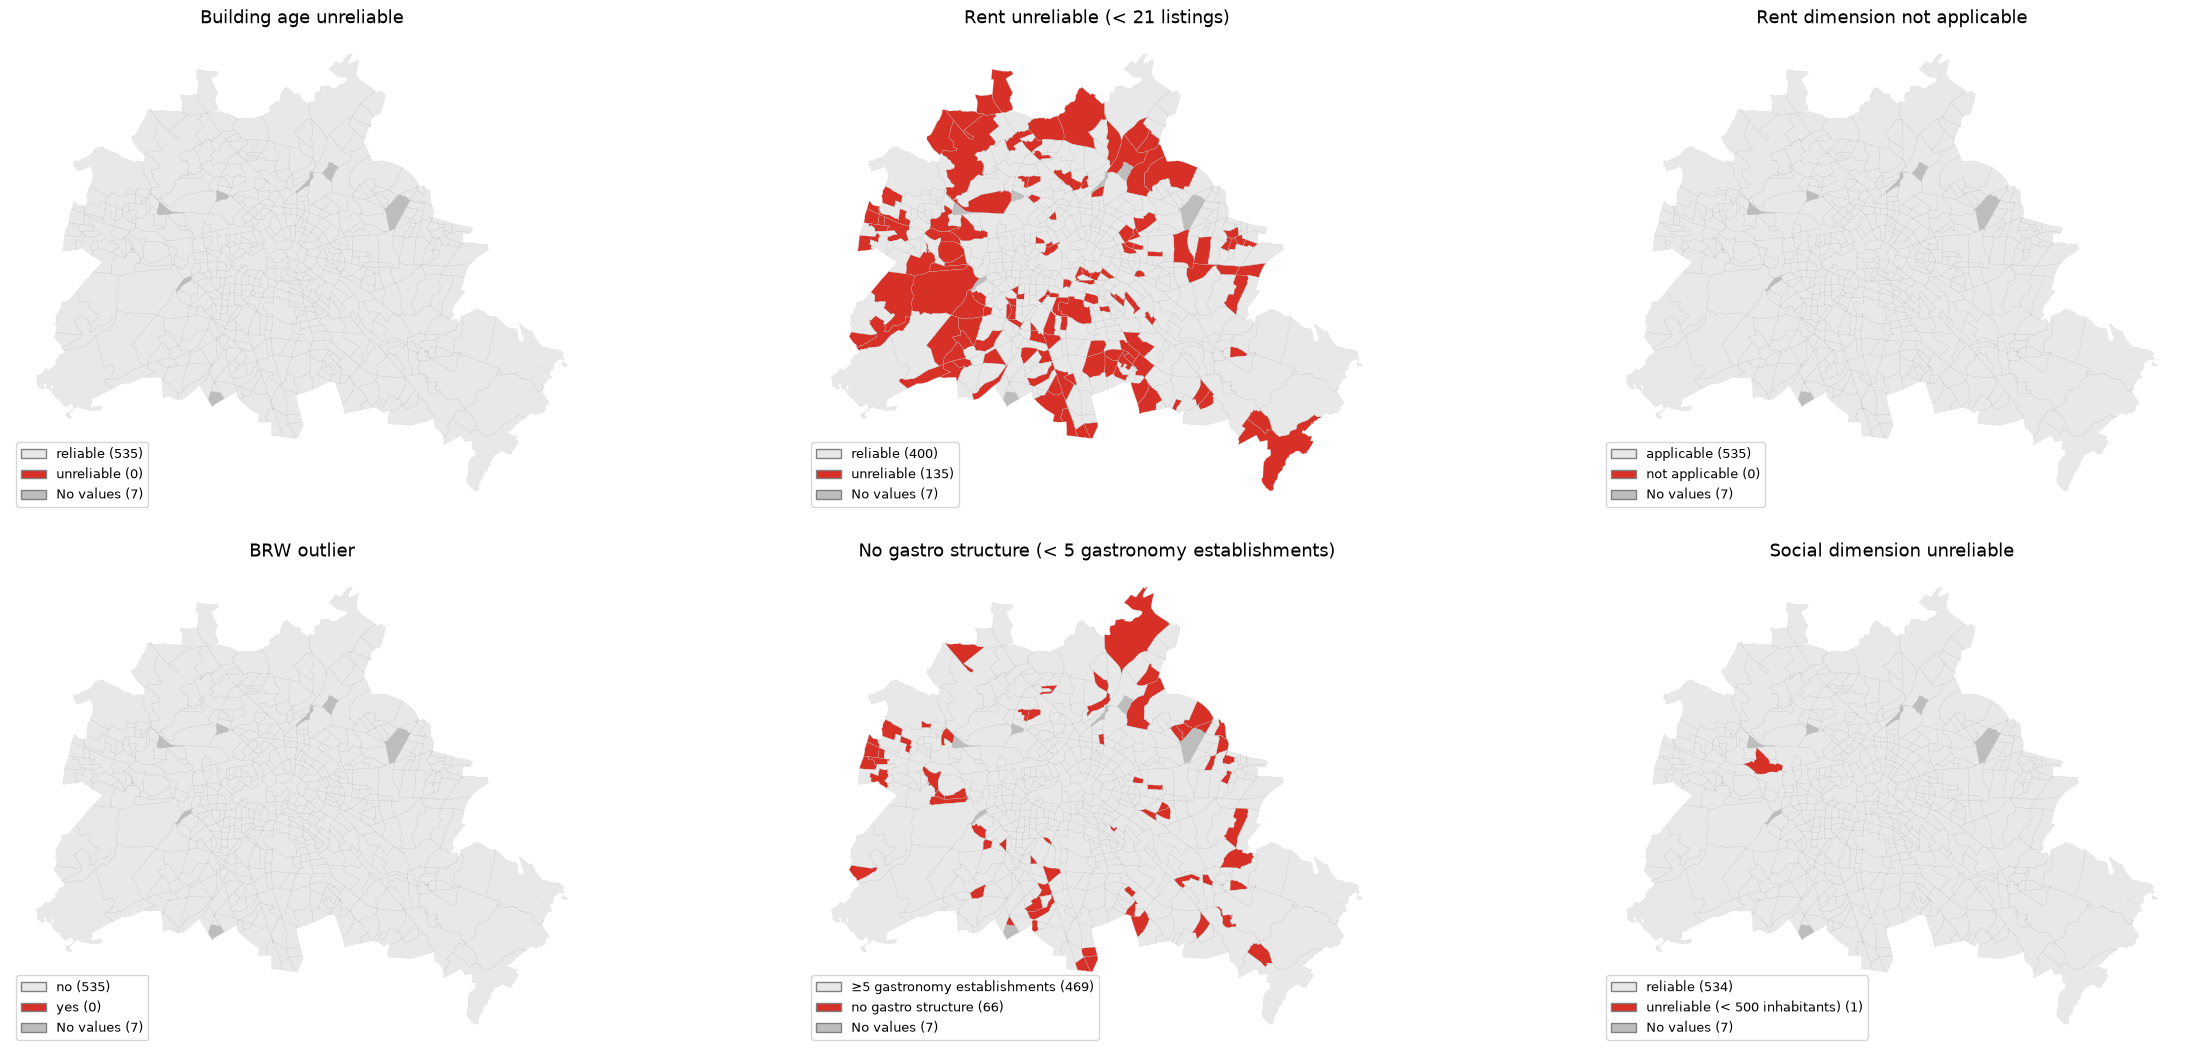

In [205]:
flags = ["re_baualter_unsicher", "re_miete_unsicher",
         "re_miet_dimension_anwendbar", "re_brw_trend_outlier","com_has_gastro_structure",
         "social_dimension_interpretable"]

df_flags = df_clean.assign(plr_id=df["plr_id"].astype(str).str.zfill(8))[["plr_id"] + flags]
gdf = plr.merge(df_flags, on="plr_id", how="left")
print(gdf[flags].notna().any(axis=1).sum(), "von", len(gdf), "gematcht")

flag_styles = {
    "re_baualter_unsicher": {"title": "Building age unreliable",
        "map": {0: ("reliable", "#e8e8e8"), 1: ("unreliable", "#d73027")}},
    "re_miete_unsicher": {"title": "Rent unreliable (< 21 listings)",
        "map": {0: ("reliable", "#e8e8e8"), 1: ("unreliable", "#d73027")}},
    "re_miet_dimension_anwendbar": {"title": "Rent dimension not applicable",
        "map": {1: ("applicable", "#e8e8e8"), 0: ("not applicable", "#d73027")}},
    "re_brw_trend_outlier": {"title": "BRW outlier",
        "map": {0: ("no", "#e8e8e8"), 1: ("yes", "#d73027")}},
    "com_has_gastro_structure": {"title": "No gastro structure (< 5 gastronomy establishments)",
        "map": {1: ("≥5 gastronomy establishments", "#e8e8e8"), 0: ("no gastro structure", "#d73027")}},
    "social_dimension_interpretable": {"title": "Social dimension unreliable",
        "map": {1: ("reliable", "#e8e8e8"),
                0:  ("unreliable (< 500 inhabitants)", "#d73027")}},
}

fig, axes = plt.subplots(3, 3, figsize=(24, 16))

for ax, (col, style) in zip(axes.flat, flag_styles.items()):
    vmap = style["map"]
    colors = gdf[col].map({k: v[1] for k, v in vmap.items()}).fillna("#bdbdbd")
    gdf.plot(ax=ax, color=colors, edgecolor="white", linewidth=0.15)
    gdf.boundary.plot(ax=ax, edgecolor="black", linewidth=0.1, alpha=0.3)

    counts = gdf[col].value_counts(dropna=False)
    handles = [Patch(facecolor=v[1], edgecolor="grey",
                     label=f"{v[0]} ({int(counts.get(k, 0))})")
               for k, v in vmap.items()]
    if gdf[col].isna().any():
        handles.append(Patch(facecolor="#bdbdbd", edgecolor="grey",
                             label=f"No values ({int(gdf[col].isna().sum())})"))
    ax.legend(handles=handles, loc="lower left", fontsize=9, frameon=True)
    ax.set_title(style["title"], fontsize=13)
    ax.axis("off")

# leere Zellen ausblenden (hier die 6.)
for ax in axes.flat[len(flag_styles):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

The dropping of the PLR with the most NA values made 3 of the flag variables obsolete. 

In [ ]:
#re_baualter_unsicher, #re_miet_dimension_anwendbar and re_brw_trend_outlier carry no more meaning and can be dropped now. 
df_clean.drop(columns=["re_baualter_unsicher","re_miet_dimension_anwendbar", "re_brw_trend_outlier"], inplace = True)

Index(['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend',
       're_miete_unsicher', 're_leerstandsquote', 're_brw_niveau',
       're_brw_trend', 're_cov_wohnen_2025', 're_dichte_all',
       're_anteil_vor_1919', 're_anteil_y1919_1948', 're_anteil_y1949_1978',
       're_anteil_y1979_1990', 're_anteil_y1991_2000', 're_anteil_y2001_2010',
       're_anteil_y2011_plus', 'soc_young_to_middle_adult_share_2025',
       'soc_young_to_middle_adult_share_change_2021_2025',
       'soc_single_person_hh_share_2024',
       'soc_single_person_hh_share_change_2021_2024',
       'soc_households_without_minor_children_share_2024',
       'soc_households_without_minor_children_share_change_2021_2024',
       'soc_internal_migration_volume_rate_2025',
       'soc_internal_migration_volume_rate_change_2021_2025',
       'soc_internal_net_migration_rate_2025',
       'soc_internal_net_migration_rate_change_2021_2025',
       'soc_transfer_benefit_share_2024',
       'soc_transfer_benef

## 4) Scaling & Imputation

In [182]:
df_clean.shape

(535, 56)